# 🔒 SIREN 用于真实 PII 数据：方法是否有效？能否分出 PII 类别？

把论文 **《LLM Safety From Within》**（arXiv:2604.18519）的方法**原样**用到真实 PII 数据上，回答两个问题：

1. **论文的方法对 PII 任务有效吗？** —— 二分类：这段文本含不含某类 PII
2. **能否更进一步，分出具体是哪一类 PII？** —— 多分类：SSN / 邮箱 / 电话 / 信用卡 / …

数据集：[`ai4privacy/pii-masking-200k`](https://huggingface.co/datasets/ai4privacy/pii-masking-200k) —— 真实自然语句 + 字符级 PII 标注（`{value, start, end, label}`），覆盖 40+ 个类别。

---

### ⚠️ 关键实验设计：正负样本都取自同一语料

这个数据集里**所有文本都含 PII，没有天然的负样本**。若拿通用语料充当负样本，就会重蹈本项目早期的覆辙：

> 早期版本用手写模板，正样本 `"SSN is 492-10-4921"`、负样本 `"Order ID is 492-10-4921"`，结果**第 1 层探针就拿到 F1 = 1.000**。因为单个判别词在词嵌入层就能分开两类，探针**根本没机会去读隐层**。

所以两个实验的正负样本**全部来自同一语料**：

| 实验 | 正样本 | 负样本 | 为什么没有捷径 |
|---|---|---|---|
| 二分类 | 含目标类 PII | 含**其他类** PII | 同一生成器、同一文风，只差标识符类型 |
| 多分类 | 判断属于哪一类 | — | 全部同源，区分类别必须真的理解标识符语义 |

**多分类是更强的证据**：领域、文风、句式全都一样，模型无法靠"这看起来像不像敏感场景"蒙对，只能真的表征出"这是社保号还是信用卡号"。

### 方法保持与论文一致
mean-pooling（式 2）· train/val/test 三分 · C 网格 `{100,200,500,1000}` **在验证集上选** · η=0.8 筛安全神经元 · α_l 由验证集性能算 · 报 **Macro-F1**

多分类下的唯一改动：`liblinear` 不支持 3 类以上，故用 **one-vs-rest** 包装（每类仍是 L1 + liblinear，与论文单类设定一致）；神经元筛选取**跨类别的最大权重**。

### 每次运行都带打乱标签对照
把训练标签打乱后重跑逐层探针。若真标签曲线是真信号，对照必须塌到**随机基线**（二分类 0.5，n 分类 1/n）。若两者都高，说明是维度过拟合而非真信号。

## 步骤 1：环境检查、克隆仓库与安装依赖

In [5]:
!nvidia-smi

# 克隆仓库，使本 Notebook 可 `import siren`（单一真源；算法逻辑不内联）
import os
if not os.path.isdir('siren-pii-probing'):
    !git clone -q https://github.com/jackyluo-learning/siren-pii-probing.git
%cd siren-pii-probing

!pip install --quiet torch transformers scikit-learn matplotlib datasets tqdm scipy

Wed Aug 26 15:27:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   38C    P8             16W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 步骤 2：先摸清数据集里有哪些 PII 类别

在选定实验类别之前，先扫一遍数据集，看各类别的出现频次。类别太稀疏的没法训练，需要按频次挑。

In [6]:
!PYTHONPATH=.:examples python -u examples/run_pii_layerwise.py --task survey --cap 4000

SIREN on real PII data — task=survey | model=Qwen/Qwen3-4B | device=cuda
扫描 4000 条文本，共出现 56 个 PII 类别。前 30 个：
    FIRSTNAME               1195  ( 29.9% 的文本含有)
    LASTNAME                 443  ( 11.1% 的文本含有)
    DATE                     409  ( 10.2% 的文本含有)
    EMAIL                    339  (  8.5% 的文本含有)
    PREFIX                   304  (  7.6% 的文本含有)
    ACCOUNTNUMBER            288  (  7.2% 的文本含有)
    AMOUNT                   284  (  7.1% 的文本含有)
    ACCOUNTNAME              281  (  7.0% 的文本含有)
    JOBAREA                  273  (  6.8% 的文本含有)
    CURRENCYSYMBOL           273  (  6.8% 的文本含有)
    TIME                     272  (  6.8% 的文本含有)
    USERNAME                 269  (  6.7% 的文本含有)
    URL                      260  (  6.5% 的文本含有)
    JOBTITLE                 257  (  6.4% 的文本含有)
    CREDITCARDNUMBER         256  (  6.4% 的文本含有)
    MIDDLENAME               255  (  6.4% 的文本含有)
    STREET                   249  (  6.2% 的文本含有)
    IPV4                     245  (  6.1% 的文本含有)
    CITY 

## 实验 1：二分类 —— 论文的方法对 PII 有效吗？

任务：**这段文本含不含 `SSN`（社保号）？**

- 正样本：含社保号的文本
- 负样本：**同一语料中含其他 PII 但不含社保号**的文本

负样本不是普通文本，而是同样谈论个人信息、同样带标识符的句子——所以探针不能靠"这段像不像敏感内容"取巧，必须分辨**标识符的类型**。

> **标签名注意**：该数据集用的是 `SSN` 而非 `SOCIALNUM`、`PHONENUMBER` 而非 `TELEPHONENUM`。写错会直接筛不出样本，脚本会列出实际存在的类别提示你。完整词表见上一步的普查输出。

想换类别就改 `--target`（如 `EMAIL`、`CREDITCARDNUMBER`、`IPV4`）。

SIREN on real PII data — task=binary | model=Qwen/Qwen3-4B | device=cuda
二分类任务「是否含 SSN」：正 373 / 负 373（负样本均含其他 PII，非普通文本）

数据划分: train 524 / val 111 / test 111 | 类别数 2
示例: 'All students, particularly those looking to become a National Mobility Specialist, ought to practice good time' -> no SSN
Loading 'Qwen/Qwen3-4B' on cuda ...
config.json: 100% 726/726 [00:00<00:00, 3.90MB/s]
tokenizer_config.json: 100% 9.73k/9.73k [00:00<00:00, 24.0MB/s]
vocab.json: 100% 2.78M/2.78M [00:00<00:00, 106MB/s]
merges.txt: 100% 1.67M/1.67M [00:00<00:00, 97.8MB/s]

tokenizer.json: downloading bytes:   0% 0.00/11.4M [00:00<?, ?B/s]
tokenizer.json: downloading bytes: 100% 3.40M/3.40M [00:01<00:00, 2.44MB/s,  330kB/s  ]
tokenizer.json: reconstructing file: 100% 11.4M/11.4M [00:01<00:00, 8.20MB/s, 1.11MB/s  ]
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
model.safetensors.index.json: 100% 32.8k/32.8k [00:00<00:00, 85.9MB/s]
Reconstructing (incomplete total...): |          |  0.00B /  0.00B   

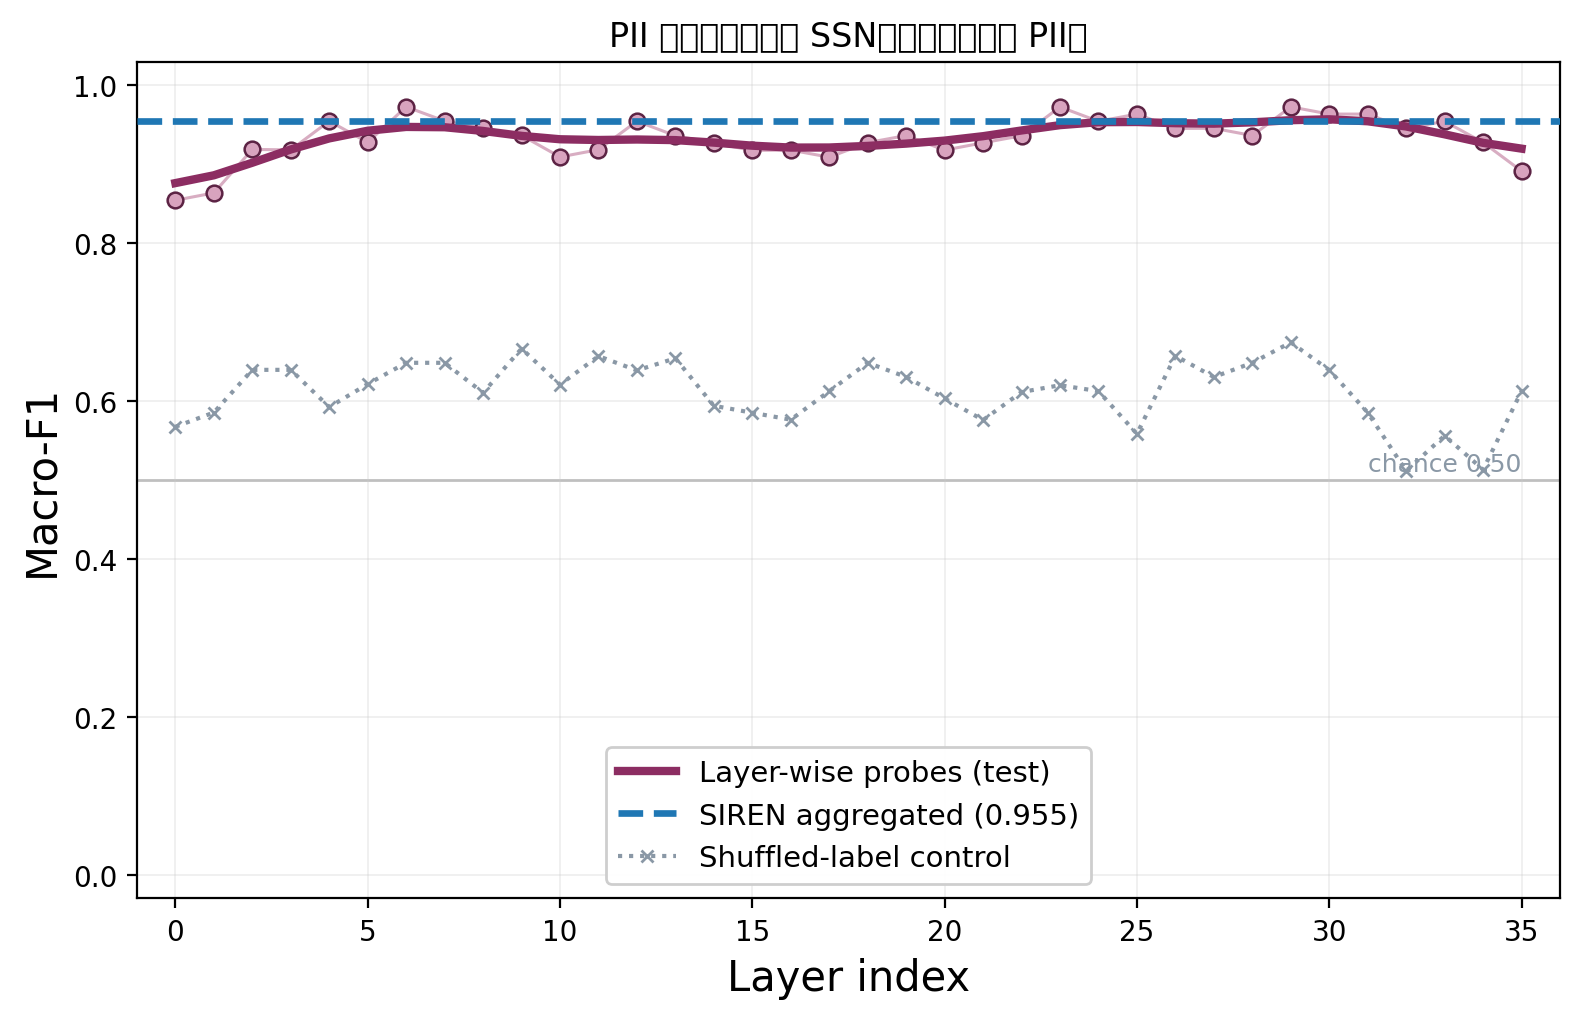

In [7]:
!PYTHONPATH=.:examples python -u examples/run_pii_layerwise.py \
    --task binary --target SSN \
    --model "Qwen/Qwen3-4B" --cap 8000 --max-length 128

from IPython.display import Image, display
display(Image('pii_binary_ssn_layers.png'))

## 实验 2：多分类 —— 能分出具体是哪一类 PII 吗？

任务：**这段文本携带的是哪一类 PII？**

只保留**恰好含一个**目标类别的文本，让标签无歧义；同时含多个目标类别的文本会被丢弃（脚本会报告丢弃数量，代价是可见的）。

这是比实验 1 更强的检验：所有样本来自同一语料、同一文风、同一生成器，**唯一的差别就是标识符的种类**。要做对，模型的内部表征必须真的把"社保号"和"信用卡号"编码成不同的东西。

产出两张图：**层级曲线**（看哪一层最能区分类别）与**混淆矩阵**（看哪些类别之间容易混淆）。

SIREN on real PII data — task=multiclass | model=Qwen/Qwen3-4B | device=cuda
未指定类别，按频次自动选取 6 个：['FIRSTNAME', 'LASTNAME', 'DATE', 'EMAIL', 'PREFIX', 'AMOUNT']
多分类任务：6 类 × 每类 162 条 = 972 条
  丢弃：同时含多个目标类别 3731 条；不含任何目标类别 10285 条
  类别：['FIRSTNAME', 'LASTNAME', 'DATE', 'EMAIL', 'PREFIX', 'AMOUNT']

数据划分: train 682 / val 145 / test 145 | 类别数 6
示例: 'Dear Jada, your next assignment at Apt. 787, make sure to use VPN with IP 178.179.101.4 for secure connection ' -> FIRSTNAME
Loading 'Qwen/Qwen3-4B' on cuda ...
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100% 398/398 [00:02<00:00, 158.39it/s]
Detected 36 transformer layers.

抽取 mean-pooled 表征（36 层）...
pooling: 100% 43/43 [00:17<00:00,  2.45batch/s]
pooling: 100% 10/10 [00:03<00:00,  2.64batch/s]
pooling: 100% 10/10 [00:03<00:00,  2.84batch/s]

逐层 L1 探针（C 网格在验证集上选，Macro-F1）...
  Layer  1: val=0.7369  test=0.7559  C=200  neurons=409
  Layer  2: val=0.7449  test=0.7984  C=1000  neurons=756
  Layer  3: val=0.7443

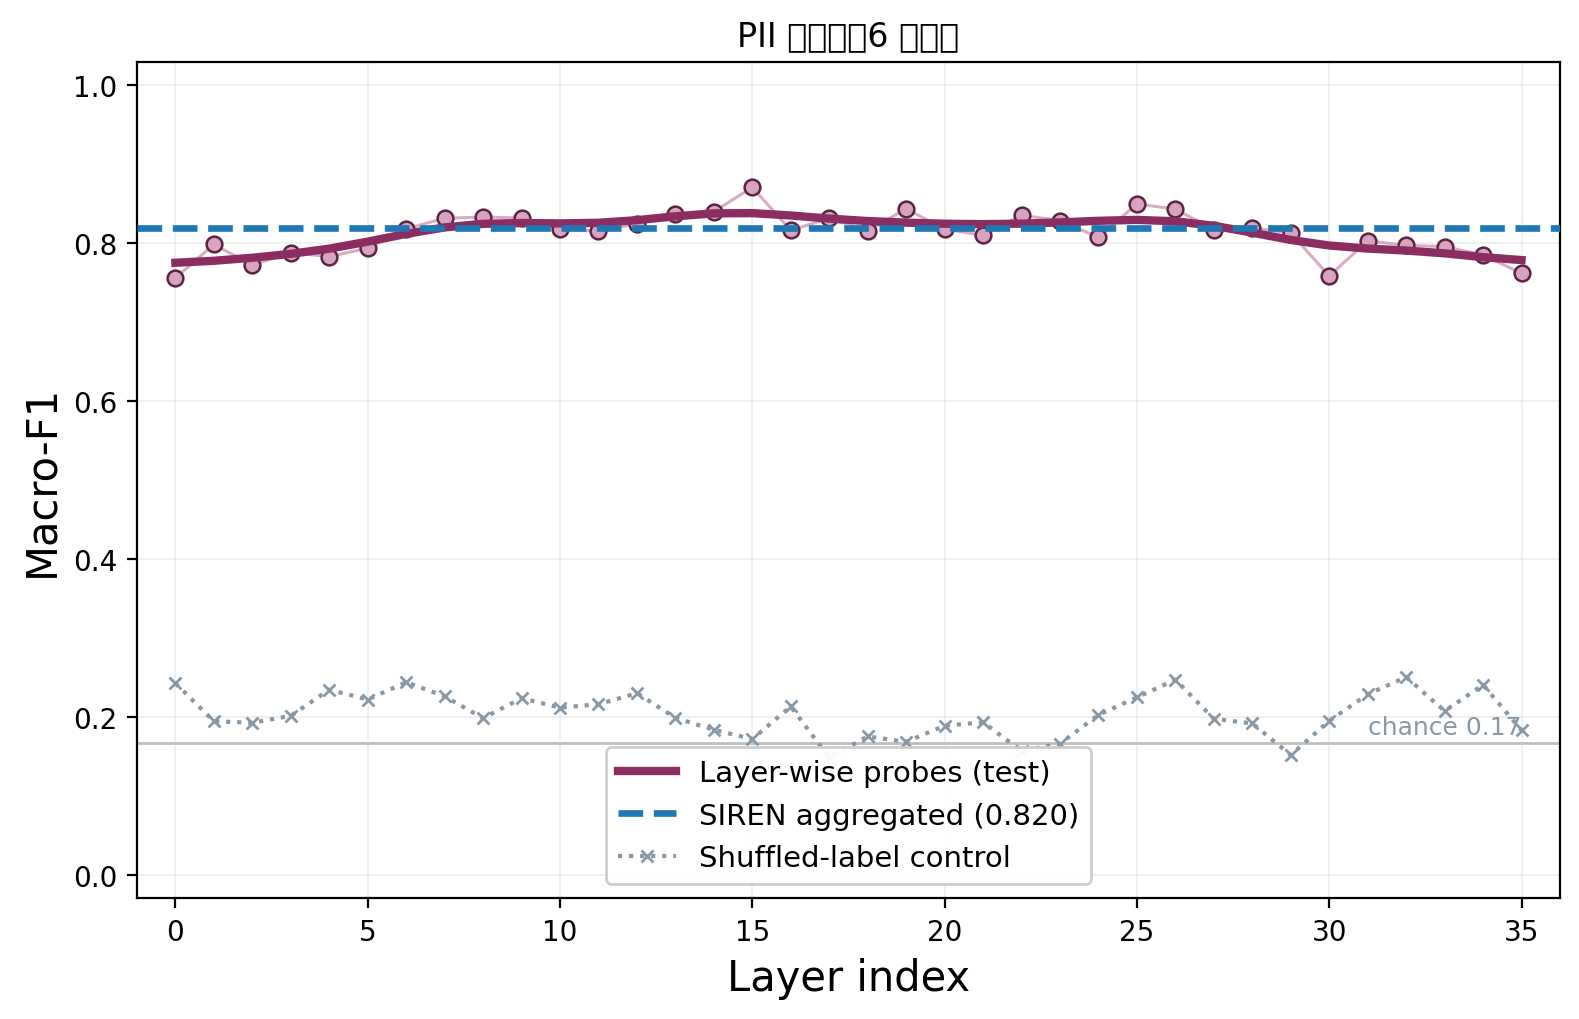

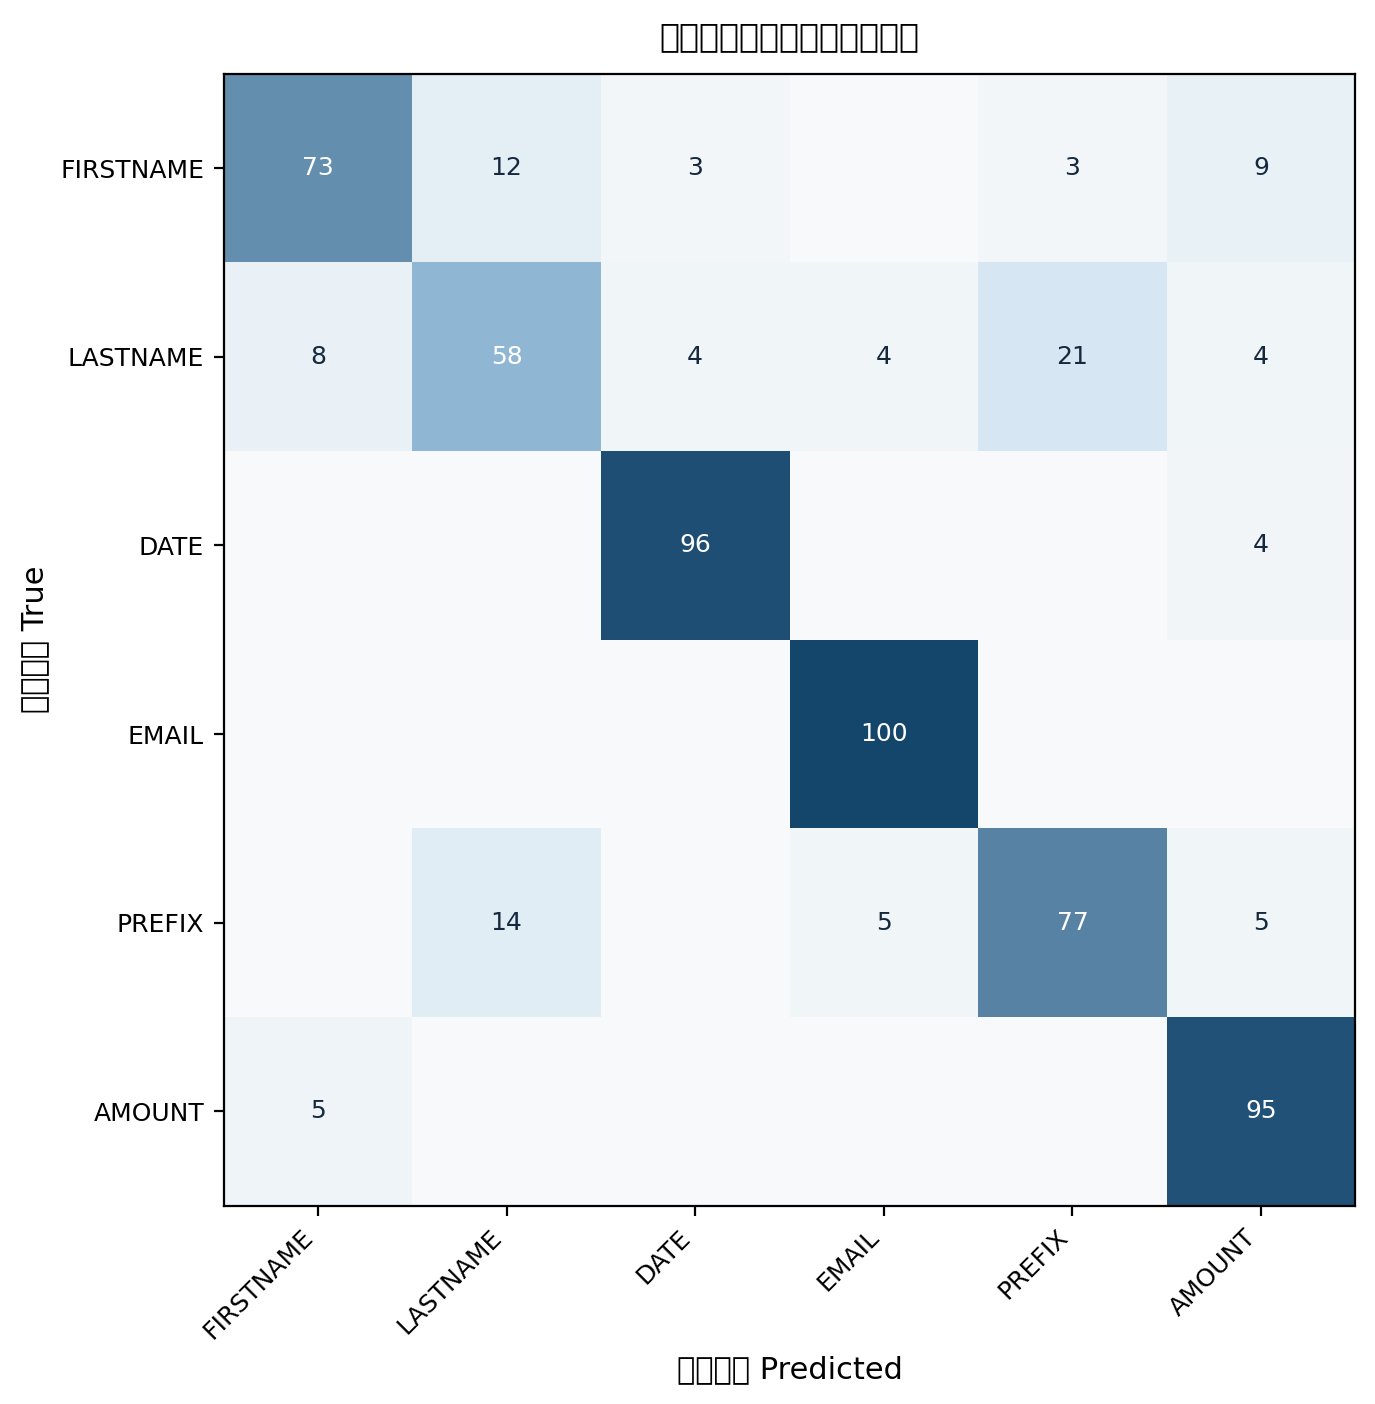

In [8]:
# 不指定 --categories 则按频次自动取前 N 个类别。
# 也可显式指定一组「标识符类型差异明显」的类别，例如：
#   --categories "EMAIL,SSN,CREDITCARDNUMBER,IPV4,PHONENUMBER,IBAN"
# 注意用数据集的真实标签名（SSN 不是 SOCIALNUM，PHONENUMBER 不是 TELEPHONENUM）。
!PYTHONPATH=.:examples python -u examples/run_pii_layerwise.py \
    --task multiclass --n-categories 6 \
    --model "Qwen/Qwen3-4B" --cap 20000 --min-per-class 80 --max-length 128

from IPython.display import Image, display
display(Image('pii_multiclass_6way_layers.png'))
display(Image('pii_multiclass_6way_confusion.png'))

## 实验 3：换一组「标识符类型」重跑多分类（cap 提到 60000）

实验 2 自动按频次选出的六类是 `FIRSTNAME / LASTNAME / DATE / EMAIL / PREFIX / AMOUNT`，其中**三个是人名成分**（名、姓、称谓 Mr./Dr.）——它们在文本里常常紧挨着出现、语义高度重叠，`LASTNAME` 的 F1 只有 0.622，几乎可以肯定是和 `FIRSTNAME` 混淆了。

这等于把问题问偏了：一半类别在考「人名的细分」，另一半在考「格式化标识符」，两者难度完全不同，混在一起看不出模型到底把 PII 类型编码到什么精度。

本实验改用**六种彼此不同的标识符类型**，每一种都有独立的格式与用途：

| 类别 | 是什么 | 语料占比 |
|---|---|---|
| `EMAIL` | 邮箱地址 | 8.5% |
| `CREDITCARDNUMBER` | 信用卡号 | 6.4% |
| `IPV4` | IP 地址 | 6.1% |
| `ACCOUNTNUMBER` | 账号 | 7.2% |
| `PASSWORD` | 密码 | 5.7% |
| `BITCOINADDRESS` | 比特币地址 | 5.5% |

同时把 `--cap` 从 20000 提到 **60000**。实验 2 因为「只保留恰好含一个目标类别」的过滤，最终每类仅 162 条、train 只有 682 条——**样本量远小于 z 维度（31656）**，这很可能就是 SIREN 融合反而比最佳单层低 0.05 的原因（融合头在小样本上过拟合）。加大 cap 是检验这个猜测的直接办法。

> 输出文件用 `--out-prefix pii_ids` 区分，不会覆盖实验 2 的图。
>
> ⏱️ cap 60000 意味着要流式扫描 6 万行原始数据，加上更多样本的前向抽取，**耗时明显长于实验 2**。

In [ ]:
!PYTHONPATH=.:examples python -u examples/run_pii_layerwise.py \
    --task multiclass \
    --categories "EMAIL,CREDITCARDNUMBER,IPV4,BITCOINADDRESS,ACCOUNTNUMBER,PASSWORD" \
    --model "Qwen/Qwen3-4B" --cap 60000 --min-per-class 80 --max-length 128 \
    --out-prefix pii_ids

from IPython.display import Image, display
display(Image('pii_ids_multiclass_6way_layers.png'))
display(Image('pii_ids_multiclass_6way_confusion.png'))